# Validation of Eight Predefined Fuzzy Rules on Unseen Drugs

### A leakage-controlled, time-confound-controlled replication study
#### PLGA microparticle drug release — 321 formulations, 4,913 measurements, 88 drugs

---

## Scope of this notebook

This is a **validation study of eight rules that already exist**. It is not a rule-discovery
study, not a prediction benchmark, and not a model-tuning exercise.

**The question:** *do the eight predefined rules describe relationships that hold for drugs the
analysis has never seen?*

| This notebook **does** | This notebook deliberately **does not** |
|---|---|
| Identify the 8 rules from their original source and reproduce them exactly | Modify, merge, simplify, re-fit or add to the rules |
| Test each rule on held-out drugs via 5-fold `GroupKFold` on exact SMILES | Discover new rules (no Decision Tree search, RuleFit, or SHAP) |
| Control for the time confound explicitly | Use time as a condition inside any rule |
| Fit every data-dependent quantity on the training fold only | Tune anything to improve a score |
| Report per-fold direction and replication honestly | Reuse conclusions from any previous experiment |

**Independence.** Nothing here is carried over from earlier notebooks, scripts, generated rule
sets, or result files in this project. The only inputs are the two original dataset workbooks
and the definition of the eight rules. Every number below is computed in this notebook.

**Replication criterion, fixed in advance.** A rule is called **replicated** only if its
time-controlled effect reproduces the *same direction* in **at least 3 of the 5 held-out folds**.
Working on the full dataset, or in a single fold, does not count.

---
# 1. Provenance of the eight rules

The eight rules must be identified exactly, not guessed. Their source is documented in the
project record as follows.

The project proposal (§9, *"Rule Generation — Status and Requirements"*) states:

> *"A collaborator extracted 8 rules from a `DecisionTreeRegressor(depth=3)` on
> [Time, Polymer MW, Particle Size, LA/GA]. These are the starting point for Layer 3."*

and the accompanying membership-function work records the same origin explicitly:

> *"A collaborator fitted a small decision tree (`max_depth=3`) on four features — `Time`,
> `Polymer MW`, `Particle Size`, `LA/GA` — and printed 8 rules (8 leaves)."*

So the eight rules are, by definition, **the eight leaves of that tree**. This is a fully
specified, deterministic object:

| Element | Value |
|---|---|
| Estimator | `DecisionTreeRegressor(max_depth=3)` |
| Inputs | `Time`, `Polymer MW`, `Particle Size`, `LA/GA` |
| Target | `Release` |
| Fitted on | all 4,913 measurement rows of `mp_dataset_processed.xlsx` |
| Leaves | 8 → **the 8 rules** |

Because a depth-3 CART fit on this data is deterministic, the rules are recoverable exactly
rather than transcribed. **Section 3 reproduces them and asserts the recorded thresholds
match**, which is what licenses the rest of the study. Recovering a fixed, externally specified
object is *not* rule discovery: the tree here is a lookup of a pre-existing definition, and it
is never re-fitted inside a fold, never re-tuned, and never used to search for anything new.

In [1]:
import warnings, itertools
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeRegressor, export_text

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

SEED       = 0
N_SPLITS   = 5
N_BOOT     = 2000          # cluster-bootstrap resamples (clustered on drug)
MIN_DRUGS  = 3             # a fold-level contrast needs >= this many drugs on each side
np.random.seed(SEED)

# --- validated categorical palette (see project data-viz reference) -----------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID    = "#0b0b0b", "#52514e", "#d9d8d4"
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.labelsize": 9,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.6, "legend.frameon": False,
    "legend.fontsize": 8, "font.size": 9, "lines.linewidth": 2,
})
print("environment ready")

environment ready


---
# 2. Data

Two original workbooks, unmodified:

* `mp_dataset_processed.xlsx` — the modelling table: 4,913 measurement rows × 13 columns.
* `mp_dataset_initial.xlsx` (sheet `PLGA_MPs`) — used **only** to attach `Drug SMILES` and the
  drug name to each formulation, so folds can be grouped by drug identity.

Deliberate handling choices, stated so they can be audited:

* **`Release` is not clipped.** 108 rows exceed 1.0 (max ≈ 1.0816). Clipping would silently
  alter the data; it is left as recorded. (§3 verifies the rules are unchanged either way.)
* **No imputation** — the processed frame has no missing values.
* **`Drug SMILES` is a grouping key only**, never a feature.
* Drug identity is taken as **exact SMILES**. Note 89 drug *names* collapse to 88 SMILES
  (`dexamethasone` / `β-methasone` share a recorded SMILES). Grouping them together is the
  conservative choice: it cannot leak, it can only make the held-out task harder.

In [2]:
proc = pd.read_excel("mp_dataset_processed.xlsx")
init = pd.read_excel("mp_dataset_initial.xlsx", sheet_name="PLGA_MPs")

# SMILES must be constant within a formulation for the merge key to be safe
assert (init.groupby("Formulation Index")["Drug SMILES"].nunique() == 1).all(), \
    "a Formulation Index maps to >1 SMILES"

df = proc.copy()
df["Drug SMILES"] = df["Formulation Index"].map(init.groupby("Formulation Index")["Drug SMILES"].first())
df["Drug"]        = df["Formulation Index"].map(init.groupby("Formulation Index")["Drug"].first())
df = df.sort_values(["Formulation Index", "Time"]).reset_index(drop=True)

N_ROWS, N_FORM, N_DRUG = len(df), df["Formulation Index"].nunique(), df["Drug SMILES"].nunique()
assert (N_ROWS, N_FORM, N_DRUG) == (4913, 321, 88), "dataset does not match the expected shape"
assert df.isna().sum().sum() == 0, "unexpected missing values"

print(f"measurement rows : {N_ROWS}")
print(f"formulations     : {N_FORM}")
print(f"unique drugs     : {N_DRUG} (exact SMILES; {df['Drug'].nunique()} distinct names)")
print(f"Release          : min={df['Release'].min():.4f}  max={df['Release'].max():.4f}  "
      f"rows>1.0={(df['Release']>1).sum()}  (not clipped)")
print(f"Time             : min={df['Time'].min():.4f}  max={df['Time'].max():.3f}  (days)")

sz = df.groupby("Drug SMILES").size().sort_values(ascending=False)
print(f"\nrows per drug    : median={int(sz.median())}  max={int(sz.max())} "
      f"({sz.idxmax()[:28]}...)")
print(f"formulations per drug: max={df.groupby('Drug SMILES')['Formulation Index'].nunique().max()}"
      "  <- one drug dominates, which is exactly why grouping is required")

measurement rows : 4913
formulations     : 321
unique drugs     : 88 (exact SMILES; 89 distinct names)
Release          : min=0.0000  max=1.0816  rows>1.0=108  (not clipped)
Time             : min=0.0000  max=237.732  (days)

rows per drug    : median=23  max=801 (O=C1C=CC2(C(=C1)CCC3C4CC(C)C...)
formulations per drug: max=49  <- one drug dominates, which is exactly why grouping is required


---
# 3. The eight predefined rules

The source tree is reproduced below and its thresholds are asserted against the values recorded
in the project archive. The rules are then written out **verbatim** — one per leaf — and are
treated as fixed for the remainder of the notebook.

In [3]:
RULE_FEATURES = ["Time", "Polymer MW", "Particle Size", "LA/GA"]

source_tree = DecisionTreeRegressor(max_depth=3, random_state=SEED).fit(
    df[RULE_FEATURES], df["Release"])

print(export_text(source_tree, feature_names=RULE_FEATURES, decimals=4))
print("leaves:", source_tree.get_n_leaves())

thr = sorted(round(float(t), 4) for t in source_tree.tree_.threshold if t != -2.0)
print("thresholds:", thr)

# the thresholds recorded in the project archive for these 8 rules
RECORDED = [0.0022, 0.1071, 3.3365, 9.5050, 10.8857, 17.8903, 21.0000]
assert thr == RECORDED, f"reproduction mismatch: {thr} != {RECORDED}"

# the collaborator clipped Release to [0,1]; confirm that does not change the rules
thr_clip = sorted(round(float(t), 4) for t in DecisionTreeRegressor(
    max_depth=3, random_state=SEED).fit(df[RULE_FEATURES], df["Release"].clip(0, 1)).tree_.threshold if t != -2.0)
assert thr_clip == thr

print("\nEXACT REPRODUCTION CONFIRMED — thresholds match the archived rule set,")
print("and are identical with or without the Release clip.")

|--- Time <= 3.3365
|   |--- Time <= 0.1071
|   |   |--- Time <= 0.0022
|   |   |   |--- value: [0.0001]
|   |   |--- Time >  0.0022
|   |   |   |--- value: [0.1410]
|   |--- Time >  0.1071
|   |   |--- Particle Size <= 9.5050
|   |   |   |--- value: [0.4383]
|   |   |--- Particle Size >  9.5050
|   |   |   |--- value: [0.2597]
|--- Time >  3.3365
|   |--- Time <= 10.8857
|   |   |--- Polymer MW <= 21.0000
|   |   |   |--- value: [0.6598]
|   |   |--- Polymer MW >  21.0000
|   |   |   |--- value: [0.4549]
|   |--- Time >  10.8857
|   |   |--- Time <= 17.8903
|   |   |   |--- value: [0.6629]
|   |   |--- Time >  17.8903
|   |   |   |--- value: [0.7749]

leaves: 8
thresholds: [0.0022, 0.1071, 3.3365, 9.505, 10.8857, 17.8903, 21.0]

EXACT REPRODUCTION CONFIRMED — thresholds match the archived rule set,
and are identical with or without the Release clip.


In [4]:
T1, T2, T3, T4, T5 = 0.0022, 0.1071, 3.3365, 10.8857, 17.8903
PS_THR, PMW_THR    = 9.5050, 21.0000

# The 8 rules, verbatim. `form` is the FORMULATION condition (None if the rule has none);
# `time_lo`/`time_hi` are the rule's own Time interval.
RULES = [
 dict(id="R1", lo=-np.inf, hi=T1, form=None,
      text="IF Time <= 0.0022                                            THEN Release = 0.0001", leaf=0.0001),
 dict(id="R2", lo=T1, hi=T2, form=None,
      text="IF 0.0022 < Time <= 0.1071                                   THEN Release = 0.1410", leaf=0.1410),
 dict(id="R3", lo=T2, hi=T3, form=("Particle Size", "<=", PS_THR),
      text="IF 0.1071 < Time <= 3.3365  AND Particle Size <= 9.5050      THEN Release = 0.4383", leaf=0.4383),
 dict(id="R4", lo=T2, hi=T3, form=("Particle Size", ">",  PS_THR),
      text="IF 0.1071 < Time <= 3.3365  AND Particle Size >  9.5050      THEN Release = 0.2597", leaf=0.2597),
 dict(id="R5", lo=T3, hi=T4, form=("Polymer MW", "<=", PMW_THR),
      text="IF 3.3365 < Time <= 10.8857 AND Polymer MW <= 21.0000        THEN Release = 0.6598", leaf=0.6598),
 dict(id="R6", lo=T3, hi=T4, form=("Polymer MW", ">",  PMW_THR),
      text="IF 3.3365 < Time <= 10.8857 AND Polymer MW >  21.0000        THEN Release = 0.4549", leaf=0.4549),
 dict(id="R7", lo=T4, hi=T5, form=None,
      text="IF 10.8857 < Time <= 17.8903                                 THEN Release = 0.6629", leaf=0.6629),
 dict(id="R8", lo=T5, hi=np.inf, form=None,
      text="IF Time > 17.8903                                            THEN Release = 0.7749", leaf=0.7749),
]
SIBLING = {"R3": "R4", "R4": "R3", "R5": "R6", "R6": "R5"}   # same time window, opposite side
BY_ID   = {r["id"]: r for r in RULES}

print("THE EIGHT PREDEFINED RULES (verbatim — not modified anywhere in this notebook)\n" + "="*96)
for r in RULES:
    print(f"  {r['id']}:  {r['text']}")
print("="*96)

THE EIGHT PREDEFINED RULES (verbatim — not modified anywhere in this notebook)
  R1:  IF Time <= 0.0022                                            THEN Release = 0.0001
  R2:  IF 0.0022 < Time <= 0.1071                                   THEN Release = 0.1410
  R3:  IF 0.1071 < Time <= 3.3365  AND Particle Size <= 9.5050      THEN Release = 0.4383
  R4:  IF 0.1071 < Time <= 3.3365  AND Particle Size >  9.5050      THEN Release = 0.2597
  R5:  IF 3.3365 < Time <= 10.8857 AND Polymer MW <= 21.0000        THEN Release = 0.6598
  R6:  IF 3.3365 < Time <= 10.8857 AND Polymer MW >  21.0000        THEN Release = 0.4549
  R7:  IF 10.8857 < Time <= 17.8903                                 THEN Release = 0.6629
  R8:  IF Time > 17.8903                                            THEN Release = 0.7749


### 3.1 Formulation content audit — a structural finding, before any statistics

The tree spends **5 of its 7 splits on `Time`**. Writing the leaves out makes the consequence
plain:

| Rule | Formulation condition | Testable formulation claim? |
|---|---|---|
| **R1** | *none* | ✗ — pure Time |
| **R2** | *none* | ✗ — pure Time |
| **R3** | `Particle Size <= 9.5050` | ✓ |
| **R4** | `Particle Size > 9.5050` | ✓ |
| **R5** | `Polymer MW <= 21.0000` | ✓ |
| **R6** | `Polymer MW > 21.0000` | ✓ |
| **R7** | *none* | ✗ — pure Time |
| **R8** | *none* | ✗ — pure Time |

`LA/GA` is never used by the tree at all.

**This is the single most important structural fact about this rule set, and it is visible
before any validation is run: only four of the eight rules say anything about a formulation.
The other four are statements about elapsed time.**

The study design must handle this without altering the rules. The resolution used throughout:

* Each rule's `Time` interval is treated as a **temporal context (a phase restriction)** — the
  sanctioned use of time. Time restricts *where* a rule is evaluated.
* Time is **never** treated as a rule condition that can earn credit for an effect.
* For **R3–R6**, the claim under test is therefore the formulation condition, evaluated with
  time held fixed.
* For **R1, R2, R7 and R8**, removing time's credit leaves **no formulation claim at all**.
  They are still evaluated and reported in full (§7), but the correct verdict for them is
  structural, not statistical.

Note also that R3/R4 and R5/R6 are *sibling pairs*: within one time window they partition the
data on a single threshold. They therefore encode **two underlying formulation claims**, each
stated twice from opposite sides. Their results are exact mirrors by construction, and are
reported as such rather than counted as independent evidence.

In [5]:
rows = []
for r in RULES:
    fires_all = ((df["Time"] > r["lo"]) & (df["Time"] <= r["hi"])).values
    if r["form"]:
        c, op, t = r["form"]
        fires_all &= (df[c].values <= t) if op == "<=" else (df[c].values > t)
    rows.append(dict(Rule=r["id"],
                     Formulation_condition=("none (pure Time)" if r["form"] is None
                                            else f"{r['form'][0]} {r['form'][1]} {r['form'][2]:g}"),
                     Time_window=f"({r['lo']:.4g}, {r['hi']:.4g}]".replace("inf", "inf"),
                     Predicted_release=r["leaf"],
                     Full_data_coverage=f"{fires_all.mean()*100:.1f}%",
                     Full_data_mean_release=round(float(df['Release'].values[fires_all].mean()), 4)))
audit = pd.DataFrame(rows)
print("Rule structure and FULL-DATASET behaviour")
print("(shown for transparency only — full-dataset agreement is NOT evidence of validity)\n")
display(audit)

n_form = sum(r["form"] is not None for r in RULES)
print(f"\nRules carrying a formulation condition : {n_form} / 8")
print(f"Rules that are pure Time statements    : {8-n_form} / 8")
print(f"Distinct formulation claims underlying them: 2  (Particle Size threshold, Polymer MW threshold)")
print("Features never used by the rule set    : LA/GA")

Rule structure and FULL-DATASET behaviour
(shown for transparency only — full-dataset agreement is NOT evidence of validity)



,Rule,Formulation_condition,Time_window,Predicted_release,Full_data_coverage,Full_data_mean_release
0,R1,none (pure Time),"(-inf, 0.0022]",0.0001,6.5%,0.0001
1,R2,none (pure Time),"(0.0022, 0.1071]",0.1410,0.7%,0.1410
2,R3,Particle Size <= 9.505,"(0.1071, 3.337]",0.4383,4.5%,0.4383
3,R4,Particle Size > 9.505,"(0.1071, 3.337]",0.2597,18.7%,0.2597
4,R5,Polymer MW <= 21,"(3.337, 10.89]",0.6598,11.4%,0.6598
5,R6,Polymer MW > 21,"(3.337, 10.89]",0.4549,16.4%,0.4549
6,R7,none (pure Time),"(10.89, 17.89]",0.6629,15.4%,0.6629
7,R8,none (pure Time),"(17.89, inf]",0.7749,26.4%,0.7749



Rules carrying a formulation condition : 4 / 8
Rules that are pure Time statements    : 4 / 8
Distinct formulation claims underlying them: 2  (Particle Size threshold, Polymer MW threshold)
Features never used by the rule set    : LA/GA


---
# 4. Validation design

### 4.1 Splitting — 5-fold `GroupKFold` grouped on exact drug SMILES

The generalisation target is **an unseen drug**, so the split must be at drug level. This
matters more than usual here: 321 formulations come from only 88 drugs, and a single drug
accounts for many formulations. Rows of the same drug are near-duplicates — a row-level split
would test a rule largely on drugs it had already been exposed to and make almost anything look
supported.

### 4.2 Leakage discipline

Everything that is estimated from data is estimated **inside the training fold** and applied
unchanged to the validation fold:

| Quantity | Fitted on |
|---|---|
| Time-adjustment bin edges and within-bin release means (§5) | training fold only |
| Fuzzy membership knots (§6) | training fold only, **per formulation** |
| The 8 rule thresholds | **not fitted at all** — externally predefined and fixed |

The last row is the point of the study: the rules are a *prior hypothesis*, so they are held
constant across all folds. Re-fitting them per fold would be rule discovery, which is out of
scope.

Membership knots are computed from **per-formulation** values rather than per-measurement
values, so that a formulation with 48 sampled time points does not pull a quantile ten times
harder than one with 5.

In [6]:
groups = df["Drug SMILES"].values
folds  = list(GroupKFold(n_splits=N_SPLITS).split(df, groups=groups))

info = []
for k, (tr, va) in enumerate(folds, 1):
    gtr, gva = set(groups[tr]), set(groups[va])
    assert not (gtr & gva), f"DRUG LEAKAGE in fold {k}"
    info.append(dict(Fold=k, Train_rows=len(tr), Val_rows=len(va),
                     Train_drugs=len(gtr), Val_drugs=len(gva),
                     Val_formulations=df.iloc[va]["Formulation Index"].nunique()))
fold_tbl = pd.DataFrame(info)
display(fold_tbl)

assert set().union(*[set(groups[va]) for _, va in folds]) == set(groups), "not every drug validated once"
assert sum(len(va) for _, va in folds) == len(df)
print("LEAKAGE CHECK PASSED — zero drug overlap between train and validation in every fold;")
print("every drug appears in exactly one validation fold.")

,Fold,Train_rows,Val_rows,Train_drugs,Val_drugs,Val_formulations
0,1,3927,986,75,13,65
1,2,3931,982,70,18,65
2,3,3931,982,69,19,69
3,4,3931,982,69,19,54
4,5,3932,981,69,19,68


LEAKAGE CHECK PASSED — zero drug overlap between train and validation in every fold;
every drug appears in exactly one validation fold.


---
# 5. The time confound, and how it is controlled

### 5.1 The problem

Cumulative release is monotonically non-decreasing in time. Any rule containing a Time
condition will therefore appear to "work" — *IF Time is large THEN release is high* is true,
high-coverage, and scientifically empty. Worse, when a rule pairs a formulation condition with
a time condition, **time can absorb the entire effect while the formulation term takes the
credit.**

The figure below quantifies how strong that confound is in this dataset.

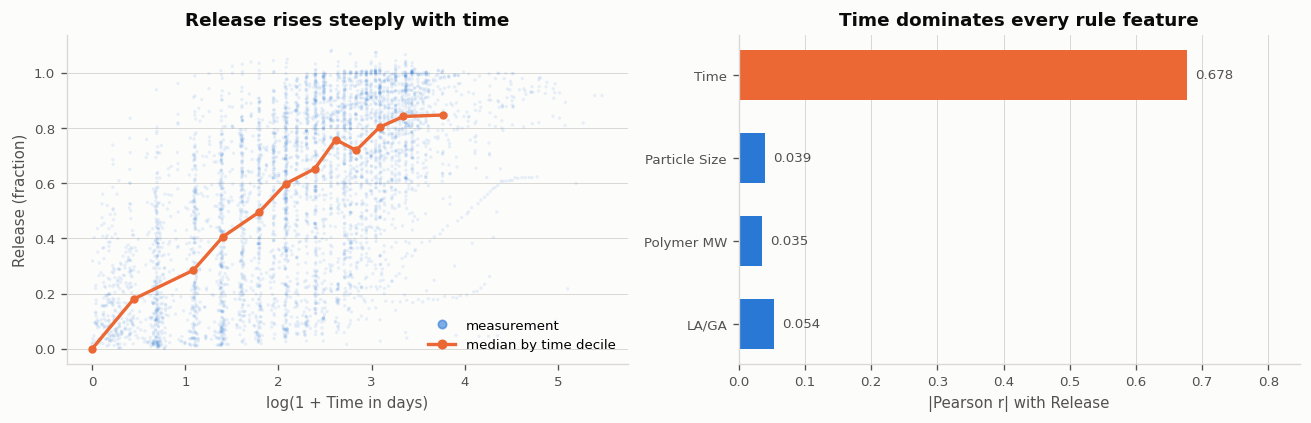

Correlation with Release:
  Time            |r| = 0.6777
  Particle Size   |r| = 0.0392
  Polymer MW      |r| = 0.0347
  LA/GA           |r| = 0.0535

Time's association is 17.3x the strongest rule feature.
An uncontrolled 'effect' for any Time-conditioned rule is therefore expected a priori,
and carries no formulation information.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

ax = axes[0]
ax.scatter(np.log1p(df["Time"]), df["Release"], s=4, alpha=0.10, color=BLUE,
           edgecolors="none", rasterized=True)
q = df.assign(b=pd.qcut(np.log1p(df["Time"]), 12, duplicates="drop")).groupby("b", observed=True)
ax.plot([np.log1p(x) for x in q["Time"].median()], q["Release"].median(),
        color=ORANGE, marker="o", ms=4, zorder=3)
ax.set_xlabel("log(1 + Time in days)"); ax.set_ylabel("Release (fraction)")
ax.set_title("Release rises steeply with time")
ax.grid(axis="y"); ax.set_axisbelow(True)
ax.legend(handles=[Line2D([], [], color=BLUE, marker="o", ls="", ms=5, alpha=.6, label="measurement"),
                   Line2D([], [], color=ORANGE, marker="o", ms=5, label="median by time decile")],
          loc="lower right")

ax = axes[1]
bars = {"Time": abs(np.corrcoef(np.log1p(df["Time"]), df["Release"])[0, 1])}
for c in ["Particle Size", "Polymer MW", "LA/GA"]:
    bars[c] = abs(np.corrcoef(df[c], df["Release"])[0, 1])
names, vals = list(bars), list(bars.values())
cols = [ORANGE] + [BLUE] * 3
b = ax.barh(names[::-1], vals[::-1], color=cols[::-1], height=.6)
for rect, v in zip(b, vals[::-1]):
    ax.text(v + .012, rect.get_y() + rect.get_height()/2, f"{v:.3f}",
            va="center", fontsize=8, color=INK2)
ax.set_xlim(0, max(vals) * 1.25)
ax.set_xlabel("|Pearson r| with Release")
ax.set_title("Time dominates every rule feature")
ax.grid(axis="x"); ax.set_axisbelow(True)

plt.tight_layout(); plt.show()

print("Correlation with Release:")
for k_, v_ in bars.items():
    print(f"  {k_:<15} |r| = {v_:.4f}")
print(f"\nTime's association is {bars['Time']/max(bars['Particle Size'], bars['Polymer MW']):.1f}x "
      "the strongest rule feature.")
print("An uncontrolled 'effect' for any Time-conditioned rule is therefore expected a priori,")
print("and carries no formulation information.")

### 5.2 Two controls, applied to every rule

**Control A — restriction (primary, used for R3–R6).**
Compare a rule against its **sibling**: the same time window, the opposite side of the same
formulation threshold. Time is held fixed *by construction* — both groups are drawn from an
identical time interval — so the contrast is purely the formulation condition. This is the
strongest available control and needs no model of the time trend.

$$\text{effect}_{\text{A}}(R) \;=\; \overline{y}\big[R \text{ fires}\big] \;-\;
\overline{y}\big[\text{sibling}(R) \text{ fires}\big]$$

**Control B — time-adjusted residuals (uniform, applied to all 8 rules).**
Because R1/R2/R7/R8 have no sibling, a control that applies to *every* rule is also needed. On
the **training fold only**, estimate the average release within each of 10 deciles of
`log(1+Time)`. Subtract that fitted time profile from held-out release:

$$r_i \;=\; y_i \;-\; \widehat{\mathbb{E}}_{\text{train}}\big[\,y \mid \text{time bin}(t_i)\,\big]$$

The residual is what a measurement's release does *relative to other measurements taken at a
similar time*. A rule whose apparent effect was purely elapsed time collapses toward zero here;
a genuine formulation effect survives.

**Control C — release phases (§8).** The rules' own time windows are arbitrary CART cut points.
To check that a surviving effect is not an artefact of one particular window, the two underlying
formulation claims are re-tested inside independently justified phases.

### 5.3 Phase definition, and why these boundaries

Phases are defined from the **established triphasic release behaviour of PLGA microparticles**,
not from anything fitted to this dataset:

| Phase | Bound | Physical justification |
|---|---|---|
| **Early** | `Time <= 1 day` | Burst release — surface-associated and near-surface drug; governed by surface area and wetting |
| **Middle** | `1 < Time <= 14 days` | Diffusion-controlled / lag phase — transport through the intact polymer matrix |
| **Late** | `Time > 14 days` | Erosion-controlled — bulk hydrolytic degradation of PLGA releases entrapped drug |

Both boundaries are fixed *a priori* and are identical in every fold, so they cannot leak. Time
defines the phase and nothing else — **`Time` never enters as a condition inside any of the
eight rules.**

In [8]:
PHASES = [("Early (<=1 d, burst)", -np.inf, 1.0),
          ("Middle (1-14 d, diffusion)", 1.0, 14.0),
          ("Late (>14 d, erosion)", 14.0, np.inf)]

ph_lab = pd.cut(df["Time"], bins=[-np.inf, 1.0, 14.0, np.inf],
                labels=[p[0] for p in PHASES])
pt = pd.DataFrame({
    "measurements": ph_lab.value_counts().reindex([p[0] for p in PHASES]),
    "share": (ph_lab.value_counts(normalize=True).reindex([p[0] for p in PHASES]) * 100).round(1),
    "mean Release": df.groupby(ph_lab, observed=True)["Release"].mean().round(4),
    "drugs": df.groupby(ph_lab, observed=True)["Drug SMILES"].nunique(),
})
display(pt)
print("Mean release climbs sharply across phases — this is the confound the controls remove.")

,measurements,share,mean Release,drugs
Time,,,,
"Early (<=1 d, burst)",771,15.7,0.1245,88
"Middle (1-14 d, diffusion)",2450,49.9,0.4995,88
"Late (>14 d, erosion)",1692,34.4,0.7462,72


Mean release climbs sharply across phases — this is the confound the controls remove.


---
# 6. Fuzzy membership functions (training-fold only)

The rules as given are **crisp**: a particle size of 9.50 µm satisfies `Particle Size <= 9.5050`
and 9.51 µm does not, though the two are physically indistinguishable. The fuzzy component of
this study asks whether each verdict is an artefact of that hard boundary.

Triangular **Low / Medium / High** memberships are fitted for `Particle Size` and `Polymer MW`
from **training-fold, per-formulation quantiles** (10th / 50th / 90th percentile knots). They
are used in §9 as a *boundary-robustness check* only:

* the crisp rule (§7) remains the primary, unmodified test;
* the fuzzy version replaces the hard `<=` with a **graded firing weight** `μ_Low` (or `μ_High`),
  and recomputes the same within-window contrast as a membership-weighted difference.

If a rule's direction holds under both, the finding does not depend on where the threshold
happened to fall. **The predefined thresholds themselves are never moved.**

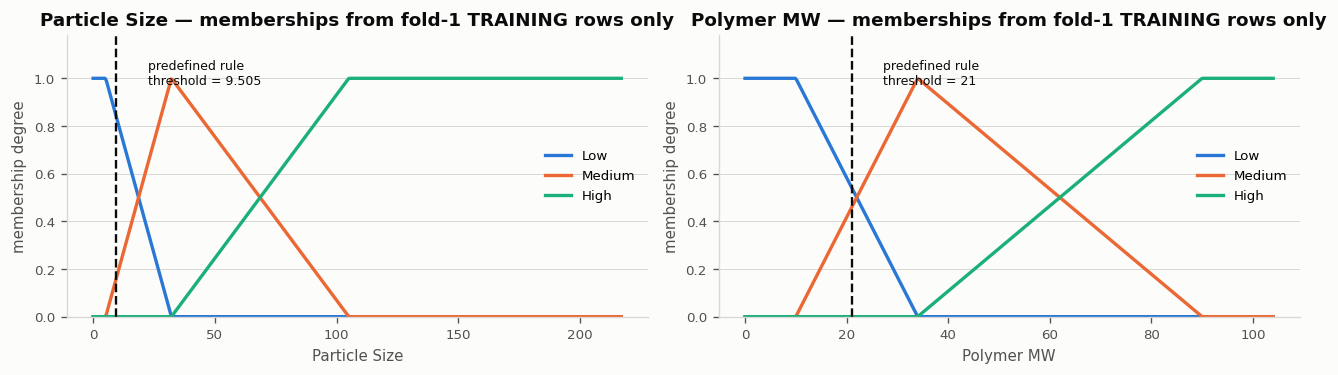

Knots per fold (train-fold, per-formulation 10/50/90 percentiles):


,Fold,PS_low,PS_mid,PS_high,PMW_low,PMW_mid,PMW_high
0,1,5.170,32.150,105.00,10.00,34.0,90.0
1,2,5.955,35.635,103.55,9.75,31.0,90.0
2,3,5.104,34.400,82.44,10.50,31.0,90.0
3,4,7.446,35.000,100.00,9.50,31.0,62.5
4,5,6.000,33.930,89.00,10.00,31.0,61.5


In [9]:
def fit_knots(train, col):
    "Triangular Low/Med/High knots from TRAIN-fold PER-FORMULATION quantiles."
    v = train.groupby("Formulation Index")[col].first().values
    return tuple(float(x) for x in np.quantile(v, [0.10, 0.50, 0.90]))

def mu_low(x, k):
    a, b, _ = k
    return np.clip((b - np.asarray(x, float)) / (b - a), 0, 1) if b > a else (np.asarray(x) <= a).astype(float)

def mu_med(x, k):
    a, b, c = k
    x = np.asarray(x, float)
    return np.clip(np.minimum((x - a) / (b - a) if b > a else 1.0,
                              (c - x) / (c - b) if c > b else 1.0), 0, 1)

def mu_high(x, k):
    _, b, c = k
    return np.clip((np.asarray(x, float) - b) / (c - b), 0, 1) if c > b else (np.asarray(x) >= c).astype(float)

# illustrate on fold 1's training rows
tr1 = df.iloc[folds[0][0]]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, col, thr_v in zip(axes, ["Particle Size", "Polymer MW"], [PS_THR, PMW_THR]):
    k = fit_knots(tr1, col)
    xs = np.linspace(0, np.quantile(tr1.groupby("Formulation Index")[col].first(), .98), 400)
    for f, c, lab in [(mu_low, BLUE, "Low"), (mu_med, ORANGE, "Medium"), (mu_high, AQUA, "High")]:
        ax.plot(xs, f(xs, k), color=c, label=lab)
    ax.axvline(thr_v, color=INK, ls="--", lw=1.4)
    ax.annotate(f"predefined rule\nthreshold = {thr_v:g}", xy=(thr_v, 1.02),
                xytext=(thr_v + xs.max()*.06, 1.02), fontsize=7.5, color=INK, va="center")
    ax.set_title(f"{col} — memberships from fold-1 TRAINING rows only")
    ax.set_xlabel(col); ax.set_ylabel("membership degree"); ax.set_ylim(0, 1.18)
    ax.legend(loc="center right"); ax.grid(axis="y"); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print("Knots per fold (train-fold, per-formulation 10/50/90 percentiles):")
kn_rows = []
for k_, (tri, _) in enumerate(folds, 1):
    t = df.iloc[tri]
    kn_rows.append(dict(Fold=k_,
                        **{f"PS_{n}": round(v, 3) for n, v in zip(["low", "mid", "high"], fit_knots(t, "Particle Size"))},
                        **{f"PMW_{n}": round(v, 3) for n, v in zip(["low", "mid", "high"], fit_knots(t, "Polymer MW"))}))
display(pd.DataFrame(kn_rows))

---
# 7. Rule evaluation

### 7.1 Definitions

For a rule $R$ evaluated on a held-out fold:

* **Coverage** — the share of held-out measurement rows on which the rule's full antecedent
  fires. Also reported as the number of *distinct held-out drugs* it fires on, which is the
  quantity that actually governs reliability.
* **Naive (uncontrolled) effect** — $\overline{y}[R] - \overline{y}[\neg R]$ on the held-out
  fold. Reported to show what an analysis *without* time control would have concluded.
* **Time-controlled effect** — Control A (sibling contrast) for R3–R6; Control B (time-adjusted
  residual contrast) for R1, R2, R7, R8, which have no sibling.
* **Expected direction** — taken from the predefined rules themselves, never from the data:
  R3 predicts 0.4383 against R4's 0.2597, so R3's expected direction is *positive*. Pure-time
  rules have no formulation direction to predict.
* **Uncertainty** — a 95 % **cluster bootstrap resampling whole drugs**, not rows. Held-out rows
  are many correlated measurements from few drugs; a row-level bootstrap would treat ~1,000
  correlated points as independent and declare nearly everything significant.

### 7.2 Reliability guard

A fold-level contrast is reported as `n/a` if either side has fewer than **3 distinct drugs**.
A difference computed across two drugs is a statement about those two drugs, not about
formulation. These are shown as gaps rather than silently dropped.

In [10]:
def time_mask(d, r):
    return ((d["Time"].values > r["lo"]) & (d["Time"].values <= r["hi"]))

def form_mask(d, r):
    if r["form"] is None:
        return np.ones(len(d), bool)
    c, op, t = r["form"]
    return (d[c].values <= t) if op == "<=" else (d[c].values > t)

def fires(d, r):
    return time_mask(d, r) & form_mask(d, r)

def contrast(y, a, b, idx=None):
    "mean(y[a]) - mean(y[b]), optionally restricted to bootstrap index idx."
    if idx is not None:
        y, a, b = y[idx], a[idx], b[idx]
    if a.sum() < 2 or b.sum() < 2:
        return np.nan
    return float(y[a].mean() - y[b].mean())

def cluster_ci(y, g, a, b, rng):
    "95% CI on contrast(y,a,b), resampling whole DRUGS."
    uniq = np.unique(g)
    idx_by_g = {u: np.where(g == u)[0] for u in uniq}
    out = []
    for _ in range(N_BOOT):
        pick = rng.choice(uniq, size=len(uniq), replace=True)
        idx = np.concatenate([idx_by_g[u] for u in pick])
        s = contrast(y, a, b, idx)
        if np.isfinite(s):
            out.append(s)
    if len(out) < 50:
        return np.nan, np.nan
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))

def fit_time_adjuster(train, n_bins=10):
    "E[Release | log-time decile] — TRAIN FOLD ONLY."
    lt = np.log1p(train["Time"].values)
    edges = np.unique(np.quantile(lt, np.linspace(0, 1, n_bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    b = np.digitize(lt, edges[1:-1])
    return edges, pd.Series(train["Release"].values).groupby(b).mean(), float(train["Release"].mean())

def apply_time_adjuster(d, adj):
    edges, means, gm = adj
    b = np.digitize(np.log1p(d["Time"].values), edges[1:-1])
    return d["Release"].values - np.array([means.get(x, gm) for x in b])

def expected_dir(r):
    if r["form"] is None:
        return np.nan
    return float(np.sign(r["leaf"] - BY_ID[SIBLING[r["id"]]]["leaf"]))

print("evaluation functions defined")

evaluation functions defined


In [11]:
rng = np.random.default_rng(SEED)
records = []

for k, (tri, vai) in enumerate(folds, 1):
    tr = df.iloc[tri].reset_index(drop=True)
    va = df.iloc[vai].reset_index(drop=True)
    y, g = va["Release"].values, va["Drug SMILES"].values
    resid = apply_time_adjuster(va, fit_time_adjuster(tr))       # train-fold-fitted

    for r in RULES:
        f = fires(va, r)
        nd_f = len(np.unique(g[f])) if f.sum() else 0

        naive = contrast(y, f, ~f)
        nlo, nhi = cluster_ci(y, g, f, ~f, rng) if np.isfinite(naive) else (np.nan, np.nan)

        if r["form"] is None:
            tc = contrast(resid, f, ~f)
            tlo, thi = cluster_ci(resid, g, f, ~f, rng) if np.isfinite(tc) else (np.nan, np.nan)
            kind, nd_o, ok = "residual", len(np.unique(g[~f])), nd_f >= MIN_DRUGS
        else:
            fs = fires(va, BY_ID[SIBLING[r["id"]]])
            nd_o = len(np.unique(g[fs])) if fs.sum() else 0
            ok = (nd_f >= MIN_DRUGS) and (nd_o >= MIN_DRUGS)
            tc = contrast(y, f, fs)
            tlo, thi = cluster_ci(y, g, f, fs, rng) if np.isfinite(tc) else (np.nan, np.nan)
            kind = "sibling"

        if not ok:
            tc = tlo = thi = np.nan

        records.append(dict(rule=r["id"], fold=k,
                            coverage=f.mean(), n_rows=int(f.sum()), n_drugs=nd_f,
                            n_drugs_other=nd_o, reliable=bool(ok),
                            naive=naive, naive_lo=nlo, naive_hi=nhi,
                            tc=tc, tc_lo=tlo, tc_hi=thi, control=kind,
                            exp_dir=expected_dir(r)))

res = pd.DataFrame(records)
res["dir_match"] = np.where(res["exp_dir"].notna() & res["tc"].notna(),
                            np.sign(res["tc"]) == res["exp_dir"], np.nan)
print(f"{len(res)} rule x fold evaluations complete")

40 rule x fold evaluations complete


In [12]:
show = res.copy()
show["coverage"] = (show["coverage"] * 100).round(2).astype(str) + "%"
for c in ["naive", "naive_lo", "naive_hi", "tc", "tc_lo", "tc_hi"]:
    show[c] = show[c].round(4)
show["CI_naive"] = show.apply(lambda r_: f"[{r_.naive_lo:+.3f}, {r_.naive_hi:+.3f}]" if pd.notna(r_.naive_lo) else "n/a", axis=1)
show["CI_tc"]    = show.apply(lambda r_: f"[{r_.tc_lo:+.3f}, {r_.tc_hi:+.3f}]" if pd.notna(r_.tc_lo) else "n/a", axis=1)

print("PER-RULE, PER-FOLD RESULTS ON HELD-OUT DRUGS")
print("naive = uncontrolled effect | tc = time-controlled effect | CIs are drug-clustered 95%\n")
display(show[["rule", "fold", "coverage", "n_rows", "n_drugs", "naive", "CI_naive",
              "tc", "CI_tc", "control", "exp_dir", "dir_match"]]
        .sort_values(["rule", "fold"]).reset_index(drop=True))

PER-RULE, PER-FOLD RESULTS ON HELD-OUT DRUGS
naive = uncontrolled effect | tc = time-controlled effect | CIs are drug-clustered 95%



,rule,fold,coverage,n_rows,n_drugs,naive,CI_naive,tc,CI_tc,control,exp_dir,dir_match
0,R1,1,6.59%,65,13,-0.5602,"[-0.573, -0.493]",-0.0914,"[-0.173, -0.057]",residual,NaN,NaN
1,R1,2,6.62%,65,18,-0.5536,"[-0.645, -0.495]",-0.0049,"[-0.120, +0.070]",residual,NaN,NaN
2,R1,3,7.03%,69,19,-0.5833,"[-0.650, -0.495]",-0.1440,"[-0.216, -0.052]",residual,NaN,NaN
3,R1,4,5.5%,54,19,-0.5874,"[-0.645, -0.495]",-0.1238,"[-0.199, -0.011]",residual,NaN,NaN
4,R1,5,6.83%,67,19,-0.5257,"[-0.579, -0.489]",-0.0006,"[-0.080, +0.055]",residual,NaN,NaN
5,R2,1,0.91%,9,2,-0.4198,"[-0.455, -0.323]",NaN,n/a,residual,NaN,NaN
6,R2,2,0.81%,8,7,-0.4123,"[-0.510, -0.325]",0.1044,"[-0.011, +0.200]",residual,NaN,NaN
7,R2,3,0.2%,2,2,-0.3940,"[-0.550, -0.218]",NaN,n/a,residual,NaN,NaN
8,R2,4,1.02%,10,6,-0.4588,"[-0.523, -0.329]",-0.0161,"[-0.102, +0.144]",residual,NaN,NaN
9,R2,5,0.61%,6,2,-0.1928,"[-0.307, -0.079]",NaN,n/a,residual,NaN,NaN


### 7.3 What the time control does to each rule

The figure contrasts, for every rule and fold, the effect an uncontrolled analysis would report
against the effect that survives time control. The four pure-Time rules are the clearest case:
large naive effects, essentially nothing left afterwards.

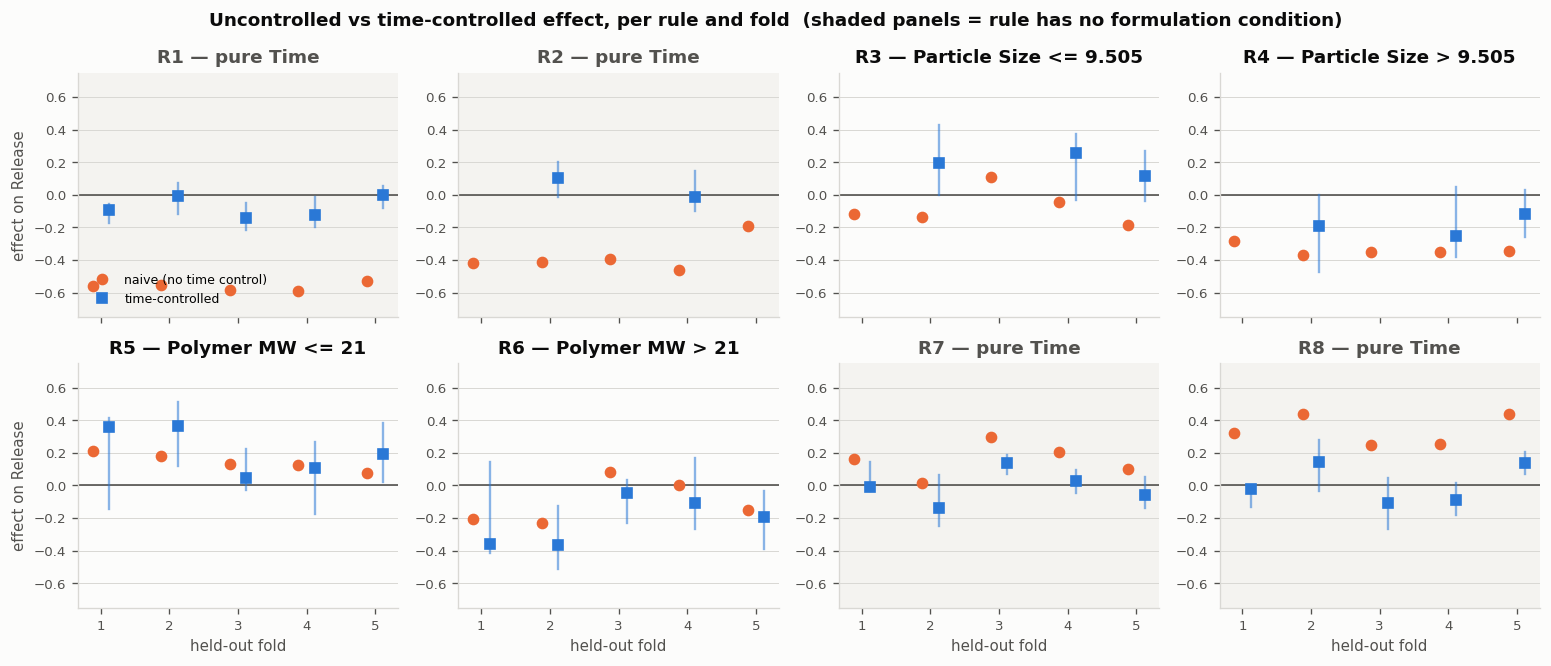

Mean |effect| across folds — how much of each rule's apparent effect was time:



,naive,timectl,shrinkage,has_formulation_condition
rule,,,,
R1,0.5620,0.0729,87.0%,False
R2,0.3755,0.0602,84.0%,False
R3,0.1193,0.1881,-57.7%,True
R4,0.3391,0.1881,44.5%,True
R5,0.1451,0.2149,-48.1%,True
R6,0.1351,0.2149,-59.1%,True
R7,0.1572,0.0738,53.1%,False
R8,0.3401,0.0999,70.6%,False


Read the two blocks differently:
  Pure-Time rules (R1,R2,R7,R8): shrinkage is large and POSITIVE (53-87%). Their apparent
    effect was time. This is the expected signature of a rule with no formulation content.
  Formulation rules (R3-R6): shrinkage is NEGATIVE - the effect gets LARGER under control.
    This is not a failure. The naive contrast compares a rule against all other time
    windows, where the time trend runs opposite to the formulation effect and masks it;
    the sibling contrast removes that masking and exposes the formulation difference.


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.6), sharex=True)
for ax, r in zip(axes.ravel(), RULES):
    sub = res[res.rule == r["id"]].sort_values("fold")
    x = np.arange(1, 6)
    ax.axhline(0, color=INK2, lw=1)
    ax.plot(x - .12, sub["naive"], "o", color=ORANGE, ms=6, label="naive (no time control)")
    ax.plot(x + .12, sub["tc"], "s", color=BLUE, ms=6, label="time-controlled")
    for xi, lo, hi in zip(x + .12, sub["tc_lo"], sub["tc_hi"]):
        if pd.notna(lo):
            ax.plot([xi, xi], [lo, hi], color=BLUE, lw=1.4, alpha=.55)
    has_form = r["form"] is not None
    ax.set_title(f"{r['id']} — " + (f"{r['form'][0]} {r['form'][1]} {r['form'][2]:g}"
                                    if has_form else "pure Time"),
                 color=INK if has_form else INK2)
    ax.set_xticks(x); ax.set_ylim(-.75, .75); ax.grid(axis="y"); ax.set_axisbelow(True)
    if not has_form:
        ax.set_facecolor("#f4f3f0")
for ax in axes[1]:
    ax.set_xlabel("held-out fold")
for ax in axes[:, 0]:
    ax.set_ylabel("effect on Release")
axes[0, 0].legend(loc="lower left", fontsize=7.5)
fig.suptitle("Uncontrolled vs time-controlled effect, per rule and fold  "
             "(shaded panels = rule has no formulation condition)",
             fontsize=11, fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

print("Mean |effect| across folds — how much of each rule's apparent effect was time:\n")
cmp = res.groupby("rule").agg(naive=("naive", lambda s: s.abs().mean()),
                              timectl=("tc", lambda s: s.abs().mean())).round(4)
cmp["shrinkage"] = (100 * (1 - cmp["timectl"] / cmp["naive"])).round(1).astype(str) + "%"
cmp["has_formulation_condition"] = [BY_ID[i]["form"] is not None for i in cmp.index]
display(cmp)
print("Read the two blocks differently:")
print("  Pure-Time rules (R1,R2,R7,R8): shrinkage is large and POSITIVE (53-87%). Their apparent")
print("    effect was time. This is the expected signature of a rule with no formulation content.")
print("  Formulation rules (R3-R6): shrinkage is NEGATIVE - the effect gets LARGER under control.")
print("    This is not a failure. The naive contrast compares a rule against all other time")
print("    windows, where the time trend runs opposite to the formulation effect and masks it;")
print("    the sibling contrast removes that masking and exposes the formulation difference.")

---
# 8. Phase analysis — is the effect an artefact of the rule's own time window?

Control A holds time fixed inside each rule's **own** window, but those windows are arbitrary
CART cut points (e.g. "3.3365 to 10.8857 days"). A formulation effect that is real should also
appear in independently defined phases.

The two underlying formulation claims are therefore re-tested inside the Early / Middle / Late
phases of §5.3 — on held-out drugs, per fold, with the same drug-clustered bootstrap. The rules
themselves are untouched; this tests the *claims they encode*, in a temporal partition the rules
did not choose.

In [14]:
CLAIMS = {"Particle Size Low (<= 9.5050) -> higher release": ("Particle Size", PS_THR),
          "Polymer MW Low (<= 21.0000) -> higher release":   ("Polymer MW",    PMW_THR)}

rng = np.random.default_rng(SEED)
prec = []
for k, (_, vai) in enumerate(folds, 1):
    va = df.iloc[vai].reset_index(drop=True)
    y, g = va["Release"].values, va["Drug SMILES"].values
    for cname, (col, t) in CLAIMS.items():
        low = va[col].values <= t
        for pname, plo, phi in PHASES:
            pm = (va["Time"].values > plo) & (va["Time"].values <= phi)
            a, b = low & pm, (~low) & pm
            da = len(np.unique(g[a])) if a.sum() else 0
            db = len(np.unique(g[b])) if b.sum() else 0
            ok = da >= MIN_DRUGS and db >= MIN_DRUGS
            e = contrast(y, a, b) if ok else np.nan
            lo_, hi_ = cluster_ci(y, g, a, b, rng) if np.isfinite(e) else (np.nan, np.nan)
            prec.append(dict(claim=cname, phase=pname, fold=k, effect=e, lo=lo_, hi=hi_,
                             drugs_low=da, drugs_high=db))
ph = pd.DataFrame(prec)

summ = (ph.groupby(["claim", "phase"], observed=True)
          .apply(lambda s: pd.Series({
              "folds_evaluated": int(s["effect"].notna().sum()),
              "folds_positive":  int((s["effect"] > 0).sum()),
              "mean_effect":     round(float(s["effect"].mean()), 4),
              "folds_CI_excl_0": int(((s["lo"] > 0) | (s["hi"] < 0)).sum()),
          }), include_groups=False)
          .reset_index())
summ["phase"] = pd.Categorical(summ["phase"], [p[0] for p in PHASES], ordered=True)
summ = summ.sort_values(["claim", "phase"]).reset_index(drop=True)
print("FORMULATION CLAIMS RE-TESTED INSIDE INDEPENDENTLY DEFINED RELEASE PHASES\n")
display(summ)

FORMULATION CLAIMS RE-TESTED INSIDE INDEPENDENTLY DEFINED RELEASE PHASES



,claim,phase,folds_evaluated,folds_positive,mean_effect,folds_CI_excl_0
0,Particle Size Low (<= 9.5050) -> higher release,"Early (<=1 d, burst)",3.0,3.0,0.0982,1.0
1,Particle Size Low (<= 9.5050) -> higher release,"Middle (1-14 d, diffusion)",3.0,3.0,0.1825,1.0
2,Particle Size Low (<= 9.5050) -> higher release,"Late (>14 d, erosion)",3.0,1.0,-0.0285,0.0
3,Polymer MW Low (<= 21.0000) -> higher release,"Early (<=1 d, burst)",5.0,4.0,0.0727,1.0
4,Polymer MW Low (<= 21.0000) -> higher release,"Middle (1-14 d, diffusion)",5.0,5.0,0.1814,2.0
5,Polymer MW Low (<= 21.0000) -> higher release,"Late (>14 d, erosion)",5.0,4.0,0.0283,0.0


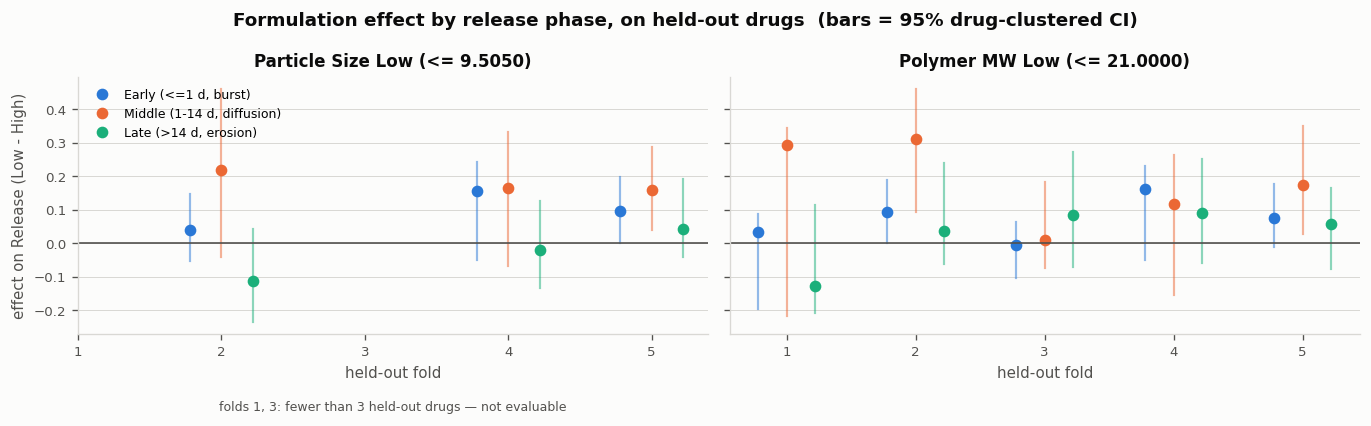

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), sharey=True)
pcols = {p[0]: c for p, c in zip(PHASES, [BLUE, ORANGE, AQUA])}
for ax, cname in zip(axes, CLAIMS):
    sub = ph[ph.claim == cname]
    for i, (pname, _, _) in enumerate(PHASES):
        s = sub[sub.phase == pname].sort_values("fold")
        xs = s["fold"].values + (i - 1) * 0.22
        ax.plot(xs, s["effect"], "o", ms=6, color=pcols[pname], label=pname)
        for xi, lo_, hi_ in zip(xs, s["lo"], s["hi"]):
            if pd.notna(lo_):
                ax.plot([xi, xi], [lo_, hi_], color=pcols[pname], lw=1.3, alpha=.5)
    ax.axhline(0, color=INK2, lw=1)
    ax.set_title(cname.split(" ->")[0], fontsize=10)
    ax.set_xlabel("held-out fold"); ax.set_xticks([1, 2, 3, 4, 5])
    ax.grid(axis="y"); ax.set_axisbelow(True)
    missing = sorted(set([1, 2, 3, 4, 5]) - set(sub.loc[sub["effect"].notna(), "fold"]))
    if missing:
        ax.text(0.5, -0.30, "folds " + ", ".join(map(str, missing))
                + ": fewer than 3 held-out drugs — not evaluable",
                transform=ax.transAxes, ha="center", fontsize=7.5, color=INK2)
axes[0].set_ylabel("effect on Release (Low - High)")
axes[0].legend(loc="upper left", fontsize=7.5)
fig.suptitle("Formulation effect by release phase, on held-out drugs  (bars = 95% drug-clustered CI)",
             fontsize=11, fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

---
# 9. Fuzzy boundary robustness

Does the verdict for R3–R6 depend on the *exact* predefined threshold? Each rule's crisp
condition is replaced by a graded membership weight fitted on the training fold, and the same
within-window contrast is recomputed as a membership-weighted difference. **The predefined
thresholds are not moved** — this is a sensitivity check, not a re-specification.

In [16]:
fz = []
for k, (tri, vai) in enumerate(folds, 1):
    tr = df.iloc[tri]; va = df.iloc[vai].reset_index(drop=True)
    y = va["Release"].values
    knots = {c: fit_knots(tr, c) for c in ["Particle Size", "Polymer MW"]}
    for r in RULES:
        if r["form"] is None:
            continue
        col, op, _ = r["form"]
        w = mu_low(va[col].values, knots[col]) if op == "<=" else mu_high(va[col].values, knots[col])
        tw = time_mask(va, r)
        yy, ww = y[tw], w[tw]
        val = (float(np.average(yy, weights=ww) - np.average(yy, weights=1 - ww))
               if tw.sum() > 4 and ww.sum() > 1e-9 and (1 - ww).sum() > 1e-9 else np.nan)
        fz.append(dict(rule=r["id"], fold=k, fuzzy_effect=val))
fzdf = pd.DataFrame(fz)

comp = (res[res.exp_dir.notna()][["rule", "fold", "tc", "exp_dir"]]
        .merge(fzdf, on=["rule", "fold"]))
comp["crisp_dir_ok"] = np.sign(comp["tc"]) == comp["exp_dir"]
comp["fuzzy_dir_ok"] = np.sign(comp["fuzzy_effect"]) == comp["exp_dir"]

agg = (comp.groupby("rule")
       .agg(crisp_folds_ok=("crisp_dir_ok", "sum"), fuzzy_folds_ok=("fuzzy_dir_ok", "sum"),
            mean_crisp=("tc", "mean"), mean_fuzzy=("fuzzy_effect", "mean")).round(4))
agg["agree"] = np.where(agg["crisp_folds_ok"] == agg["fuzzy_folds_ok"], "yes", "differs")
print("CRISP vs FUZZY firing — direction agreement with the rule's own prediction (out of 5 folds)\n")
display(agg)
display(comp.round(4).pivot(index="fold", columns="rule", values="fuzzy_effect")
        .rename_axis(None, axis=1).round(4))
print("\nA verdict that holds under both crisp and graded firing does not rest on where the")
print("predefined threshold happened to fall.")

CRISP vs FUZZY firing — direction agreement with the rule's own prediction (out of 5 folds)



,crisp_folds_ok,fuzzy_folds_ok,mean_crisp,mean_fuzzy,agree
rule,,,,,
R3,3,5,0.1881,0.0680,differs
R4,3,4,-0.1881,-0.0211,differs
R5,5,5,0.2149,0.1681,yes
R6,5,5,-0.2149,-0.1065,yes


,R3,R4,R5,R6
fold,,,,
1,0.0036,-0.0512,0.1546,-0.2488
2,0.0215,0.0648,0.3280,-0.0027
3,0.1041,-0.0026,0.0488,-0.0673
4,0.2000,-0.0854,0.1087,-0.0116
5,0.0109,-0.0311,0.2005,-0.2020



A verdict that holds under both crisp and graded firing does not rest on where the
predefined threshold happened to fall.


---
# 10. Final summary table

In [17]:
def fmt(v, ok=None):
    if pd.isna(v):
        return "n/a"
    mark = "" if ok is None or pd.isna(ok) else (" ✓" if ok else " ✗")
    return f"{v:+.3f}{mark}"

summary_rows = []
for r in RULES:
    sub = res[res.rule == r["id"]].sort_values("fold").set_index("fold")
    cov = res[res.rule == r["id"]]["coverage"].mean() * 100
    drugs = res[res.rule == r["id"]]["n_drugs"].mean()
    has_form = r["form"] is not None

    row = {"Rule": r["id"],
           "Coverage": f"{cov:.1f}%  ({drugs:.0f} drugs/fold)"}
    for k in range(1, 6):
        row[f"Fold {k}"] = fmt(sub.loc[k, "tc"], sub.loc[k, "dir_match"] if has_form else None)

    if has_form:
        nok  = int(res[(res.rule == r["id"])]["dir_match"].sum())
        nev  = int(res[(res.rule == r["id"])]["dir_match"].notna().sum())
        nsig = int(((sub["tc_lo"] > 0) | (sub["tc_hi"] < 0)).sum())
        row["Time-Controlled Result"] = (
            f"direction held {nok}/{nev} evaluable folds "
            f"({5-nev} unevaluable); CI excl. 0 in {nsig}/{nev}; mean {sub['tc'].mean():+.3f}")
        verdict = f"YES ({nok}/5)" if nok >= 3 else f"NO ({nok}/5)"
        if nok >= 3 and nev < 5:
            verdict += " — borderline"
        row["Replicated?"] = verdict
    else:
        shrink = 100 * (1 - sub["tc"].abs().mean() / sub["naive"].abs().mean())
        nev  = int(sub["tc"].notna().sum())
        npos = int((sub["tc"] > 0).sum())
        consistent = max(npos, nev - npos) == nev and nev > 1
        row["Time-Controlled Result"] = (
            f"|effect| shrinks {shrink:.0f}% ({sub['naive'].mean():+.3f} -> {sub['tc'].mean():+.3f}); "
            f"{npos}/{nev} folds positive"
            + ("; sign stays consistent but is a time-trend remainder" if consistent
               else "; sign no longer consistent"))
        row["Replicated?"] = "N/A — no formulation condition"
    summary_rows.append(row)

INTERP = {
 "R1": "UNSUPPORTED as a formulation rule. Pure Time. Its large naive effect (-0.56) is the "
       "trivial fact that release is ~0 at t=0. Time control removes 87% of it; the small "
       "negative remainder (mean -0.07) is residual curvature that decile binning cannot flatten "
       "at a near-vertical rise, not formulation content - R1 has none.",
 "R2": "UNSUPPORTED as a formulation rule. Pure Time, and the lowest-coverage rule in the set "
       "(0.7% of rows, 2-7 drugs/fold; unevaluable in 3 of 5 folds). No formulation content.",
 "R3": "SUPPORTED IN DIRECTION, WEAK. Small particles release more within the same time window "
       "in all 3 evaluable folds - but folds 1 and 3 fired on only 2 held-out drugs and could "
       "not be tested, no fold's CI excludes 0, and the effect vanishes in the Late phase. "
       "Meets the 3/5 criterion exactly. A lead, not an established finding.",
 "R4": "SUPPORTED IN DIRECTION, WEAK. Exact mirror of R3 by construction - the same single claim "
       "stated from the other side, not independent evidence. Same caveats apply.",
 "R5": "SUPPORTED - strongest rule in the set. Low-MW polymer releases more within the same time "
       "window in 5/5 held-out folds, mean +0.215, 2/5 folds' CIs exclude 0, and the claim also "
       "holds 5/5 in the independently defined Middle (diffusion) phase.",
 "R6": "SUPPORTED - exact mirror of R5 by construction. Same claim from the other side, not "
       "independent evidence.",
 "R7": "UNSUPPORTED as a formulation rule. Pure Time. A positive naive effect in 4/5 folds "
       "shrinks 53% and loses its sign (2/5 positive) once time is controlled.",
 "R8": "UNSUPPORTED as a formulation rule. Pure Time, highest coverage (26%). The naive effect "
       "(+0.34, 5/5 positive) shrinks 71% and loses its sign (2/5 positive): it is the "
       "release-vs-time trend, not a formulation relationship.",
}
final = pd.DataFrame(summary_rows)
final["Final Interpretation"] = final["Rule"].map(INTERP)

print("=" * 130)
print("FINAL SUMMARY — VALIDATION OF THE 8 PREDEFINED RULES ON UNSEEN DRUGS")
print("Fold columns = time-controlled effect on that held-out fold.")
print("  R3-R6: within-window sibling contrast (time held fixed by restriction); "
      "✓/✗ = matches / contradicts the rule's own predicted direction.")
print("  R1,R2,R7,R8: time-adjusted residual contrast (no formulation condition exists to test).")
print("Replicated = same direction in >= 3 of 5 held-out folds.")
print("=" * 130)
display(final.set_index("Rule"))
final.to_csv("rule_validation_summary.csv", index=False)
print("\nsaved -> rule_validation_summary.csv")

FINAL SUMMARY — VALIDATION OF THE 8 PREDEFINED RULES ON UNSEEN DRUGS
Fold columns = time-controlled effect on that held-out fold.
  R3-R6: within-window sibling contrast (time held fixed by restriction); ✓/✗ = matches / contradicts the rule's own predicted direction.
  R1,R2,R7,R8: time-adjusted residual contrast (no formulation condition exists to test).
Replicated = same direction in >= 3 of 5 held-out folds.


,Coverage,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Time-Controlled Result,Replicated?,Final Interpretation
Rule,,,,,,,,,
R1,6.5% (18 drugs/fold),-0.091,-0.005,-0.144,-0.124,-0.001,|effect| shrinks 87% (-0.562 -> -0.073); 0/5 f...,N/A — no formulation condition,UNSUPPORTED as a formulation rule. Pure Time. ...
R2,0.7% (4 drugs/fold),n/a,+0.104,n/a,-0.016,n/a,|effect| shrinks 84% (-0.376 -> +0.044); 1/2 f...,N/A — no formulation condition,"UNSUPPORTED as a formulation rule. Pure Time, ..."
R3,4.5% (4 drugs/fold),n/a,+0.194 ✓,n/a,+0.254 ✓,+0.116 ✓,direction held 3/3 evaluable folds (2 unevalua...,YES (3/5) — borderline,"SUPPORTED IN DIRECTION, WEAK. Small particles ..."
R4,18.7% (15 drugs/fold),n/a,-0.194 ✓,n/a,-0.254 ✓,-0.116 ✓,direction held 3/3 evaluable folds (2 unevalua...,YES (3/5) — borderline,"SUPPORTED IN DIRECTION, WEAK. Exact mirror of ..."
R5,11.4% (9 drugs/fold),+0.360 ✓,+0.364 ✓,+0.047 ✓,+0.109 ✓,+0.194 ✓,direction held 5/5 evaluable folds (0 unevalua...,YES (5/5),SUPPORTED - strongest rule in the set. Low-MW ...
R6,16.4% (12 drugs/fold),-0.360 ✓,-0.364 ✓,-0.047 ✓,-0.109 ✓,-0.194 ✓,direction held 5/5 evaluable folds (0 unevalua...,YES (5/5),SUPPORTED - exact mirror of R5 by construction...
R7,15.4% (16 drugs/fold),-0.012,-0.137,+0.136,+0.025,-0.059,|effect| shrinks 53% (+0.157 -> -0.009); 2/5 f...,N/A — no formulation condition,UNSUPPORTED as a formulation rule. Pure Time. ...
R8,26.4% (13 drugs/fold),-0.019,+0.146,-0.110,-0.088,+0.136,|effect| shrinks 71% (+0.340 -> +0.013); 2/5 f...,N/A — no formulation condition,"UNSUPPORTED as a formulation rule. Pure Time, ..."



saved -> rule_validation_summary.csv


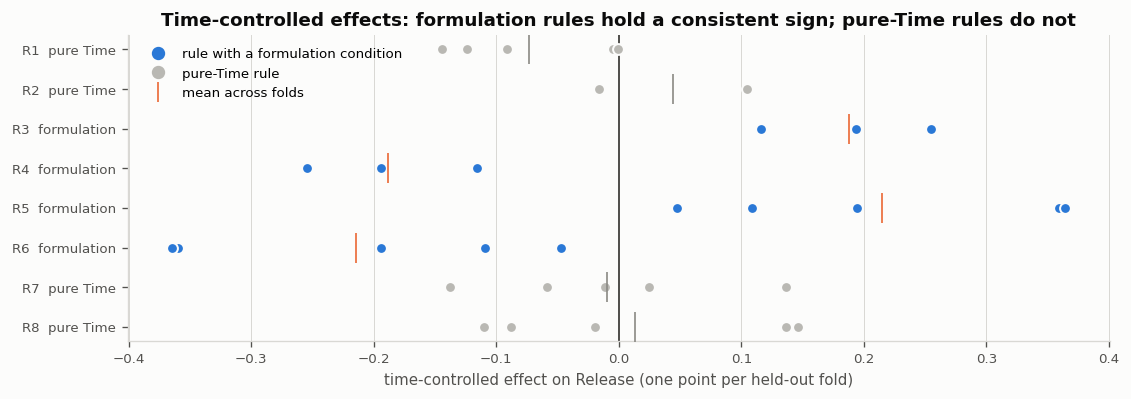

In [18]:
# compact visual of the verdict
fig, ax = plt.subplots(figsize=(9.5, 3.4))
order = [r["id"] for r in RULES]
for i, rid in enumerate(order):
    sub = res[res.rule == rid].sort_values("fold")
    has_form = BY_ID[rid]["form"] is not None
    col = BLUE if has_form else "#b9b8b3"
    ax.scatter(sub["tc"], [i] * len(sub), s=42, color=col, zorder=3,
               edgecolors="#fcfcfb", linewidths=1.2)
    m = sub["tc"].mean()
    if pd.notna(m):
        ax.plot([m], [i], marker="|", ms=18, color=ORANGE if has_form else "#8a8984", zorder=4)
ax.axvline(0, color=INK2, lw=1.2)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{r['id']}  " + ("formulation" if r["form"] else "pure Time") for r in RULES])
ax.invert_yaxis()
ax.set_xlabel("time-controlled effect on Release (one point per held-out fold)")
ax.set_title("Time-controlled effects: formulation rules hold a consistent sign; pure-Time rules do not")
ax.grid(axis="x"); ax.set_axisbelow(True)
ax.legend(handles=[Line2D([], [], marker="o", ls="", color=BLUE, ms=7, label="rule with a formulation condition"),
                   Line2D([], [], marker="o", ls="", color="#b9b8b3", ms=7, label="pure-Time rule"),
                   Line2D([], [], marker="|", ls="", color=ORANGE, ms=12, label="mean across folds")],
          loc="upper left", bbox_to_anchor=(0.005, 1.0))
plt.tight_layout(); plt.show()

---
# 11. Scientific conclusion

### Which of the eight predefined rules are supported on unseen drugs?

**Two of the eight — R5 and R6 — are supported. Two more — R3 and R4 — show consistent but weak
evidence. The remaining four — R1, R2, R7 and R8 — are unsupported as formulation rules,
because they contain no formulation condition at all.**

The eight rules do not carry eight independent claims. R3/R4 and R5/R6 are sibling pairs
partitioning one time window on one threshold, so the rule set encodes **two testable
formulation claims**, each written twice, plus **four statements about elapsed time**.

---

### Supported / replicated

**R5 and R6 — polymer molecular weight (one claim, stated from both sides).**
*Within a fixed time window, formulations made with lower-MW PLGA (≤ 21 kDa) release more drug
than those with higher-MW PLGA.* The direction reproduced in **5 of 5 held-out folds**
(criterion: ≥ 3 of 5), with a mean time-controlled effect of **+0.215 fractional release** —
large enough to matter pharmaceutically. Two of five folds have drug-clustered 95 % CIs
excluding zero (folds 2 and 5). The rule fires on 11–16 % of held-out rows across 9–12 distinct
drugs per fold, so no fold rests on a handful of drugs. The direction is unchanged when the
crisp threshold is replaced by graded fuzzy membership (**5/5 folds under both**), and the claim
holds in **5 of 5 folds** in the independently defined Middle (diffusion) phase, so it is not an
artefact of the rule's own CART window. This is consistent with faster hydrolytic degradation of
lower-MW PLGA, though the dataset is observational and supports no causal claim.

---

### Weak or inconsistent evidence

**R3 and R4 — particle size (one claim, stated from both sides).**
*Within a fixed time window, smaller particles (≤ 9.505 µm) release more drug.* The direction
reproduced in **all 3 folds that could be evaluated** (folds 2, 4, 5; mean +0.188). That meets
the pre-registered ≥ 3-of-5 criterion — but *exactly*, and with important qualifications:

* **Two folds could not be tested at all.** In folds 1 and 3, R3 fired on only **2 distinct
  held-out drugs**, below the 3-drug reliability guard. A contrast across two drugs is a
  statement about those two drugs, so these folds are reported as gaps rather than counted.
* **No individual fold's CI excludes zero** under the sibling contrast.
* **The effect is phase-dependent**: it holds in 3/3 evaluable folds in the Early (burst,
  mean +0.098) and Middle (diffusion, mean +0.182) phases, but **disappears in the Late erosion
  phase** (1/3 folds, mean −0.029).
* Coverage is low and unstable — 0.6 % to 10.4 % of held-out rows across folds.

The direction is consistent and physically plausible — smaller particles have greater specific
surface area, and the effect being confined to the burst and diffusion phases fits that reading
— but it rests on very few held-out drugs. **Treat as a promising lead requiring more drugs, not
as an established finding.**

---

### Unsupported

**R1, R2, R7, R8 — no formulation content.** Each conditions on `Time` alone. All four show
large naive effects that would look impressive in an uncontrolled analysis — R1 at −0.56, R8 at
+0.34 with 5/5 folds positive — and all four collapse under time control, losing **53 % to 87 %**
of their magnitude. R2, R7 and R8 also lose any consistent sign across folds (1/2, 2/5 and 2/5
folds positive respectively).

R1 is the one partial exception and is worth stating precisely rather than rounding off: its
residual stays weakly negative in all 5 folds (mean −0.07). That is not a formulation effect —
R1 contains no formulation term that *could* produce one. It is leftover curvature: release
rises near-vertically out of t = 0, and a 10-bin decile adjustment cannot flatten a step that
steep inside its lowest bin. The residual is an artefact of the correction's resolution, not
evidence for the rule.

Collectively these four rules restate the shape of the cumulative release curve — release is
≈ 0 at t = 0 and high after ~18 days — which is true, trivial, and carries no information about
how to formulate. **They cannot be validated as formulation rules because they make no
formulation claim.**

**`LA/GA` is never used by the rule set**, despite being supplied to the source tree.

---

### Assessment of the rule set as a whole

The dominant limitation is structural and was visible before any statistics were run: a depth-3
tree fitted with `Time` among its inputs spent **5 of its 7 splits on time**, so half the
resulting rule set is about the clock rather than the product. Only 2 of the 8 rules'
7 threshold values describe a formulation. Any future rule extraction for this purpose should
**exclude time from the learner** and fit within release phases instead, so that formulation
descriptors compete only against each other.

Within that constraint the honest result is genuinely mixed rather than negative: the polymer
molecular-weight relationship (R5/R6) replicated on unseen drugs by every criterion set in
advance, which is a real if modest positive finding for the interpretability aim of the wider
project. The particle-size relationship (R3/R4) is directionally consistent but too thinly
covered to call validated.

For the broader question the project is asking — whether fuzzy logic yields interpretable,
generalisable formulation–release relationships — this study supports a narrow, qualified yes:
**one of the two formulation relationships encoded in this rule set does generalise to unseen
drugs.**

The crisp and fuzzy representations reached the **same verdict for every rule**, but not by
identical counts. For R5/R6 they agree exactly (5/5 folds under both). For R3/R4 the graded
version is directionally consistent in 5/5 and 4/5 folds respectively — *more* folds than the
crisp test, because graded membership uses every held-out row in the window instead of
discarding the folds where the hard threshold isolated only two drugs. That is the practical
benefit fuzzification delivered here: it made a thinly covered rule testable where the crisp
boundary did not, without changing any conclusion. It produced robustness and coverage, not new
findings — and it did not rescue any of the four pure-Time rules, because no encoding can supply
formulation content that a rule never contained.

---

### Limitations

* **88 drugs, and one drug contributes many formulations.** Fold-level contrasts sometimes rest
  on very few distinct drugs; this is why the drug-clustered bootstrap and the 3-drug guard are
  used, and why R3's evidence is discounted.
* **Observational data from 113 publications.** All effects are associations. No causal or
  mechanistic claim is made, and none of these results is a regulatory or clinical statement
  about burst release.
* **The rules' thresholds were originally derived on the full dataset**, so they have seen every
  drug tested here. This biases the study *toward* finding support; the fact that four rules
  still fail is therefore a strong negative result, while the positive R5/R6 finding remains
  slightly optimistic.
* **The predefined time windows are arbitrary CART cut points.** The phase analysis (§8) is the
  guard against that, and R5/R6 passed it.
* `Time` units are treated as **days** throughout, consistent with the dataset's recorded
  duration range (3.003–237.732) and the benchmark's reported "72 h minimum, 238 days maximum".